In [1]:
!pip install pandas numpy matplotlib seaborn pyspark fpdf -q

  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum, avg, count, month, year, col
from fpdf import FPDF
import os

In [3]:
os.makedirs("dataset", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

In [4]:
def dataset_generation_agent(rows=5000):
    np.random.seed(42)

    products = ["Laptop", "Mobile", "Headphones", "Tablet", "Smartwatch", "Camera"]
    regions = ["South", "North", "East", "West"]
    categories = ["Electronics", "Accessories", "Gadgets"]

    data = {
        "customer_id": np.arange(1, rows + 1),
        "product_name": np.random.choice(products, rows),
        "category": np.random.choice(categories, rows),
        "region": np.random.choice(regions, rows),
        "quantity": np.random.randint(1, 10, rows),
        "unit_price": np.random.randint(500, 80000, rows),
        "purchase_date": pd.date_range(start="2025-01-01", periods=rows, freq="H")
    }

    df = pd.DataFrame(data)

    df.loc[10:20, "unit_price"] = np.nan
    df.loc[30:35, "region"] = np.nan

    df.to_csv("dataset/generated_sales.csv", index=False)

    return df


df = dataset_generation_agent()
df.head()

/tmp/ipykernel_4983/985350681.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "purchase_date": pd.date_range(start="2025-01-01", periods=rows, freq="H")


,customer_id,product_name,category,region,quantity,unit_price,purchase_date
0,1,Tablet,Gadgets,East,8,4378.0,2025-01-01 00:00:00
1,2,Smartwatch,Electronics,North,7,2449.0,2025-01-01 01:00:00
2,3,Headphones,Gadgets,West,2,21381.0,2025-01-01 02:00:00
3,4,Smartwatch,Electronics,East,1,51806.0,2025-01-01 03:00:00
4,5,Smartwatch,Electronics,West,7,10458.0,2025-01-01 04:00:00


In [5]:
def data_cleaning_agent(df):
    df = df.drop_duplicates()

    df["unit_price"] = df["unit_price"].fillna(df["unit_price"].mean())
    df["region"] = df["region"].fillna(df["region"].mode()[0])

    df["product_name"] = df["product_name"].str.strip()
    df["region"] = df["region"].str.strip()

    df.to_csv("dataset/cleaned_sales.csv", index=False)

    return df


cleaned_df = data_cleaning_agent(df)
cleaned_df.isnull().sum()

,0
customer_id,0
product_name,0
category,0
region,0
quantity,0
unit_price,0
purchase_date,0


In [6]:
def transformation_agent(df):
    df["total_revenue"] = df["quantity"] * df["unit_price"]
    df["month"] = pd.to_datetime(df["purchase_date"]).dt.month
    df["year"] = pd.to_datetime(df["purchase_date"]).dt.year

    df["revenue_per_item"] = df["total_revenue"] / df["quantity"]

    df = pd.get_dummies(df, columns=["region", "category"], drop_first=True)

    df.to_csv("dataset/transformed_sales.csv", index=False)

    return df


transformed_df = transformation_agent(cleaned_df.copy())
transformed_df.head()

,customer_id,product_name,quantity,unit_price,purchase_date,total_revenue,month,year,revenue_per_item,region_North,region_South,region_West,category_Electronics,category_Gadgets
0,1,Tablet,8,4378.0,2025-01-01 00:00:00,35024.0,1,2025,4378.0,False,False,False,False,True
1,2,Smartwatch,7,2449.0,2025-01-01 01:00:00,17143.0,1,2025,2449.0,True,False,False,True,False
2,3,Headphones,2,21381.0,2025-01-01 02:00:00,42762.0,1,2025,21381.0,False,False,True,False,True
3,4,Smartwatch,1,51806.0,2025-01-01 03:00:00,51806.0,1,2025,51806.0,False,False,False,True,False
4,5,Smartwatch,7,10458.0,2025-01-01 04:00:00,73206.0,1,2025,10458.0,False,False,True,True,False


In [7]:
spark = SparkSession.builder.appName("Agentic_Data_Engineering_Pipeline").getOrCreate()

spark_df = spark.createDataFrame(cleaned_df)

spark_df.show(5)

+-----------+------------+-----------+------+--------+----------+-------------------+
|customer_id|product_name|   category|region|quantity|unit_price|      purchase_date|
+-----------+------------+-----------+------+--------+----------+-------------------+
|          1|      Tablet|    Gadgets|  East|       8|    4378.0|2025-01-01 00:00:00|
|          2|  Smartwatch|Electronics| North|       7|    2449.0|2025-01-01 01:00:00|
|          3|  Headphones|    Gadgets|  West|       2|   21381.0|2025-01-01 02:00:00|
|          4|  Smartwatch|Electronics|  East|       1|   51806.0|2025-01-01 03:00:00|
|          5|  Smartwatch|Electronics|  West|       7|   10458.0|2025-01-01 04:00:00|
+-----------+------------+-----------+------+--------+----------+-------------------+
only showing top 5 rows


In [8]:
spark_df = spark_df.withColumn("total_revenue", col("quantity") * col("unit_price"))
spark_df = spark_df.withColumn("month", month(col("purchase_date")))
spark_df = spark_df.withColumn("year", year(col("purchase_date")))

region_revenue = spark_df.groupBy("region").agg(
    sum("total_revenue").alias("total_revenue")
)

product_revenue = spark_df.groupBy("product_name").agg(
    sum("total_revenue").alias("total_revenue")
)

monthly_revenue = spark_df.groupBy("month").agg(
    sum("total_revenue").alias("total_revenue")
).orderBy("month")

category_revenue = spark_df.groupBy("category").agg(
    sum("total_revenue").alias("total_revenue")
)

region_pd = region_revenue.toPandas()
product_pd = product_revenue.toPandas()
monthly_pd = monthly_revenue.toPandas()
category_pd = category_revenue.toPandas()

region_pd

,region,total_revenue
0,South,2.660398e+08
1,East,2.487195e+08
2,West,2.412920e+08
3,North,2.373543e+08


In [9]:
total_revenue = cleaned_df["quantity"].mul(cleaned_df["unit_price"]).sum()
total_orders = len(cleaned_df)
average_order_value = total_revenue / total_orders
top_region = region_pd.sort_values("total_revenue", ascending=False).iloc[0]["region"]
top_product = product_pd.sort_values("total_revenue", ascending=False).iloc[0]["product_name"]

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)
print("Top Region:", top_region)
print("Top Product:", top_product)

Total Revenue: 993405628.0276608
Total Orders: 5000
Average Order Value: 198681.12560553217
Top Region: South
Top Product: Smartwatch


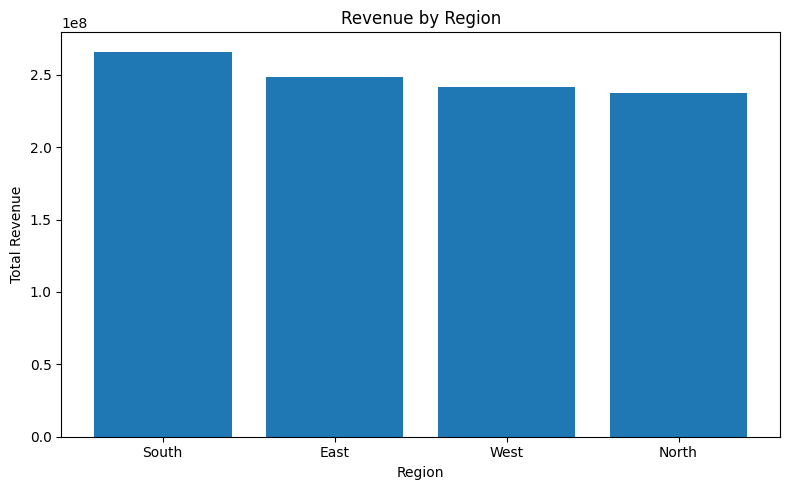

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(region_pd["region"], region_pd["total_revenue"])
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("visualizations/revenue_by_region.png")
plt.show()

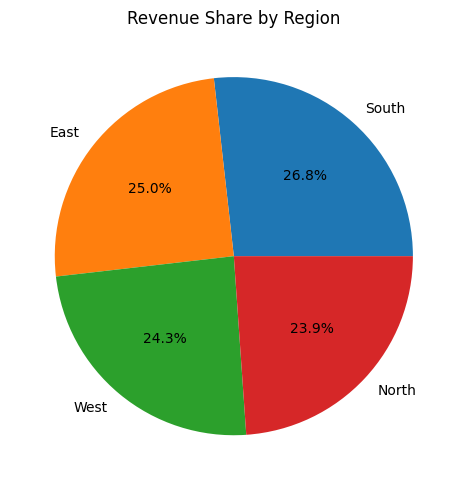

In [11]:
plt.figure(figsize=(8, 5))
plt.pie(
    region_pd["total_revenue"],
    labels=region_pd["region"],
    autopct="%1.1f%%"
)
plt.title("Revenue Share by Region")
plt.tight_layout()
plt.savefig("visualizations/revenue_share_region.png")
plt.show()

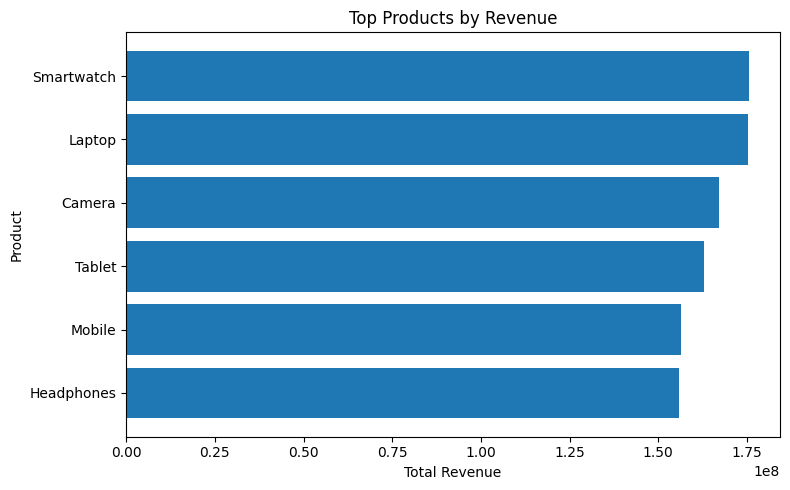

In [12]:
top_products = product_pd.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top_products["product_name"], top_products["total_revenue"])
plt.title("Top Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("visualizations/top_products.png")
plt.show()

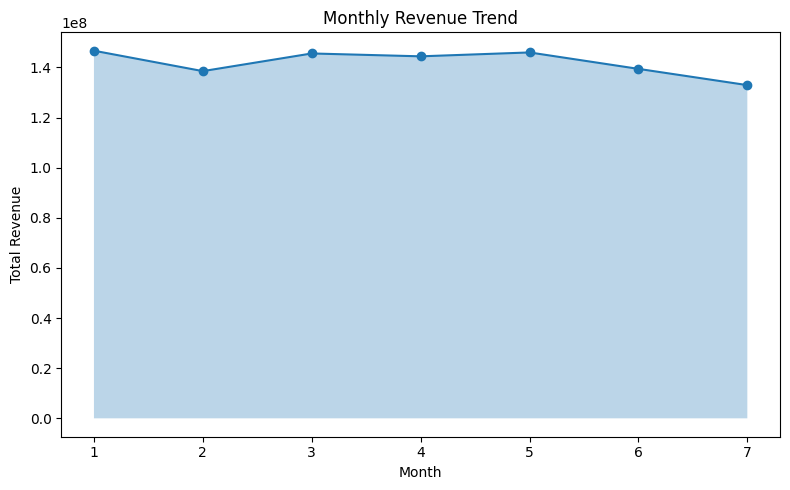

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_pd["month"], monthly_pd["total_revenue"], marker="o")
plt.fill_between(monthly_pd["month"], monthly_pd["total_revenue"], alpha=0.3)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("visualizations/monthly_revenue_trend.png")
plt.show()

In [14]:
def insight_generation_agent():
    insights = []

    insights.append(f"The total revenue generated is ₹{total_revenue:,.2f}.")
    insights.append(f"The dataset contains {total_orders} total orders.")
    insights.append(f"The average order value is ₹{average_order_value:,.2f}.")
    insights.append(f"The highest revenue generating region is {top_region}.")
    insights.append(f"The best performing product is {top_product}.")

    return insights


insights = insight_generation_agent()

for i in insights:
    print("-", i)

- The total revenue generated is ₹993,405,628.03.
- The dataset contains 5000 total orders.
- The average order value is ₹198,681.13.
- The highest revenue generating region is South.
- The best performing product is Smartwatch.


In [15]:
markdown_report = f"""
# Agentic Data Engineering Pipeline Report

## Project Title
End-to-End Agentic Data Engineering Pipeline

## Dataset Summary
- Total Records: {total_orders}
- Total Revenue: ₹{total_revenue:,.2f}
- Average Order Value: ₹{average_order_value:,.2f}
- Top Region: {top_region}
- Top Product: {top_product}

## Agents Used
1. Dataset Generation Agent
2. Data Cleaning Agent
3. Data Transformation Agent
4. PySpark Processing Agent
5. Analytics Agent
6. Report Generation Agent

## Key Insights
"""

for insight in insights:
    markdown_report += f"\n- {insight}"

with open("reports/final_report.md", "w") as file:
    file.write(markdown_report)

print(markdown_report)


# Agentic Data Engineering Pipeline Report

## Project Title
End-to-End Agentic Data Engineering Pipeline

## Dataset Summary
- Total Records: 5000
- Total Revenue: ₹993,405,628.03
- Average Order Value: ₹198,681.13
- Top Region: South
- Top Product: Smartwatch

## Agents Used
1. Dataset Generation Agent
2. Data Cleaning Agent
3. Data Transformation Agent
4. PySpark Processing Agent
5. Analytics Agent
6. Report Generation Agent

## Key Insights

- The total revenue generated is ₹993,405,628.03.
- The dataset contains 5000 total orders.
- The average order value is ₹198,681.13.
- The highest revenue generating region is South.
- The best performing product is Smartwatch.


In [17]:
def insight_generation_agent():
    insights = []

    insights.append(f"The total revenue generated is Rs. {total_revenue:,.2f}.")
    insights.append(f"The dataset contains {total_orders} total orders.")
    insights.append(f"The average order value is Rs. {average_order_value:,.2f}.")
    insights.append(f"The highest revenue generating region is {top_region}.")
    insights.append(f"The best performing product is {top_product}.")

    return insights


insights = insight_generation_agent()

In [18]:
class PDFReport(FPDF):
    def header(self):
        self.set_font("Arial", "B", 14)
        self.cell(0, 10, "Agentic Data Engineering Pipeline Report", ln=True, align="C")
        self.ln(5)

    def chapter_title(self, title):
        self.set_font("Arial", "B", 12)
        self.cell(0, 10, title, ln=True)
        self.ln(3)

    def chapter_body(self, body):
        self.set_font("Arial", "", 11)
        self.multi_cell(0, 8, body)
        self.ln()


pdf = PDFReport()
pdf.add_page()

pdf.chapter_title("Project Overview")
pdf.chapter_body(
    "This project demonstrates an end-to-end agentic data engineering pipeline. "
    "It generates a dataset, cleans the data, performs transformation, processes it using PySpark, "
    "generates KPIs, creates visualizations, and produces an automated final report."
)

pdf.chapter_title("KPI Summary")
pdf.chapter_body(
    f"Total Records: {total_orders}\n"
    f"Total Revenue: Rs. {total_revenue:,.2f}\n"
    f"Average Order Value: Rs. {average_order_value:,.2f}\n"
    f"Top Region: {top_region}\n"
    f"Top Product: {top_product}"
)

pdf.chapter_title("Key Insights")
for insight in insights:
    pdf.chapter_body("- " + insight)

pdf.chapter_title("Visualizations")

image_files = [
    "visualizations/revenue_by_region.png",
    "visualizations/revenue_share_region.png",
    "visualizations/top_products.png",
    "visualizations/monthly_revenue_trend.png"
]

for image in image_files:
    pdf.image(image, w=170)
    pdf.ln(8)

pdf.output("reports/final_report.pdf")

print("PDF report generated successfully!")

PDF report generated successfully!


In [19]:
from google.colab import files

files.download("dataset/generated_sales.csv")
files.download("dataset/cleaned_sales.csv")
files.download("dataset/transformed_sales.csv")
files.download("reports/final_report.md")
files.download("reports/final_report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>